#  HI fluxes

Here we aim to explore the HI fluxes from different catalogs using [edge_pydb](https://github.com/tonywong94/edge_pydb)

1. edge_leda (647 entries, but only 453 have fluxes)
2. edge_hiflux (161 entries; edge2015 and some more)
3. CALIFA_HI_sample_archive.csv (923 entries)
4. hiedge_all.csv (568 entries)


5. FASHI (41741 entries)
6. ALFALFA  (31502 entries) 

Also of use

1. iEDGE (643 entries) 
2. edge_califa (671 entries)
3. amusing (621 entries)

See also (private repo) https://github.com/tonywong94/edge_hispec/


# Tables used below

Below the short table names in the code, the number of entries, and the `key` of the galaxy name for any join/merging operations.

```   
 t0   edge_califa.csv                  671   Name
 t1   edge_leda.csv                    647   Name
 t2   iedge_v1.ecsv                    643   CALIFA_name
 t3   edge_hiflux.csv                  159   Name              only has names, no ra,dec
 t4   edge2025.csv                      43   Name              only has names, no ra,dec
 t5   CALIFA_HI_sample_archive.csv     923   CALIFA_name       562 have flux, 361 have no archived flux
 t6   hiedge_all.csv                   568   Name              only names, from veselina's spectra plots
 t7   amusing_sample_char.csv          621   Amusing_Name      only 20 in overlap with CALIFA
 t8   xCOLDGASS.txt                    532   SDSS Name         xCOLDGASS_PubCat.fits for full catalogue
 a100 a100.code12.table2.190808.csv  31502   -                 probably should use the OC coordinates, not HI
 fast Table2-FASHI*catalog.csv       41741   -

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.io import ascii
from astropy.table import QTable, Table, join
from astropy.coordinates import SkyCoord, Distance
from astropy import units as u
try:
    from edge_pydb import EdgeTable
    print("edge_pydb installed")
except:
    print("No edge_pydb installed, no EdgeTable avaiable")
    


edge_pydb installed


In [2]:
def common(t1, t2, c1, c2, mask=False):
    """ return a selection of t1 where c1 in t1 matches a c2 in t2"""
    mask12 = np.isin(t1[c1], t2[c2])
    n12 = len(t1[mask12])
    print("common",len(t1),len(t2), "->", n12)
    if mask:
        return mask12
    return t1[mask12]

In [3]:
EdgeTable('list')

Choose from the following files to read:
manga_global.csv
manga_global_dr15.csv
edge_bbpars_natv.csv
edge_jampars.csv
edge_rdist17.csv
edge_rfpars.csv
edge_bbpars_smo7.csv
ecalifa_global.csv
edge_califa.csv
edge_wise.csv
ecalifa_ned.csv
ecalifa_leda.csv
edge_leda.csv
.#edge_leda.csv
edge_ned.csv
edge_nsa.csv
edge_coflux_smo7.csv
edge_coflux_natv.csv
edge_coobs_DE.csv
junk.csv
edge_coobs_D.csv
edge_coflux_e20.csv
edge_coobs_E.csv
iedge_v1.csv
edge_hiflux.csv
NGC4047.cocube_smo7.hdf5
edge_cospec_e20.csv
edge_cospec_natv.csv
edge_cospec_smo7.csv
NGC4047_allpix.pipe3d.hdf5
rf_CO_natv.csv
rf_HA_smo6.csv
rf_HA_natv.csv
rf_CO_smo6.csv
rprof_de20_smo.csv
rprof_smo7_smo.csv
jam_rotcurves.csv
bb_natv_fitvd_dilmsk.csv
bb_natv_fitvd_dilmsk_freepa.csv
bb_natv_fixvd_dilmsk.csv
bb_smo7_fitvd_dilmsk.csv
bb_smo7_fitvd_dilmsk_freepa.csv
bb_smo7_fixvd_dilmsk_freepa.csv
bb_smo7_fixvd_dilmsk.csv
bb_natv_fixvd_dilmsk_freepa.csv
NGC4047_hex.2d_smo7.hdf5
NGC4047.2d_smo7.hdf5
EDGE_COparameters_20180515.csv
jam

<EdgeTable length=0>
<No columns>

In [4]:
# there's a "bug" in edge_pydb in that it doesn't recognize ecsv yet. I have a PR coming
if True:
    from edge_pydb import util
    util.updatefiles()
    EdgeTable('list')

PJT
Choose from the following files to read:
manga_global.csv
manga_global_dr15.csv
edge_bbpars_natv.csv
edge_jampars.csv
edge_rdist17.csv
edge_rfpars.csv
edge_bbpars_smo7.csv
ecalifa_global.csv
edge_califa.csv
edge_wise.csv
ecalifa_ned.csv
ecalifa_leda.csv
edge_leda.csv
.#edge_leda.csv
edge_ned.csv
edge_nsa.csv
edge_coflux_smo7.csv
edge_coflux_natv.csv
edge_coobs_DE.csv
junk.csv
edge_coobs_D.csv
edge_coflux_e20.csv
edge_coobs_E.csv
iedge_v1.csv
edge_hiflux.csv
NGC4047.cocube_smo7.hdf5
edge_cospec_e20.csv
edge_cospec_natv.csv
edge_cospec_smo7.csv
NGC4047_allpix.pipe3d.hdf5
rf_CO_natv.csv
rf_HA_smo6.csv
rf_HA_natv.csv
rf_CO_smo6.csv
rprof_de20_smo.csv
rprof_smo7_smo.csv
jam_rotcurves.csv
bb_natv_fitvd_dilmsk.csv
bb_natv_fitvd_dilmsk_freepa.csv
bb_natv_fixvd_dilmsk.csv
bb_smo7_fitvd_dilmsk.csv
bb_smo7_fitvd_dilmsk_freepa.csv
bb_smo7_fixvd_dilmsk_freepa.csv
bb_smo7_fixvd_dilmsk.csv
bb_natv_fixvd_dilmsk_freepa.csv
NGC4047_hex.2d_smo7.hdf5
NGC4047.2d_smo7.hdf5
EDGE_COparameters_20180515.csv

In [5]:
# note the comment line became a row
amusing = EdgeTable('amusing_sample_char.csv')
amusing.keys()
amusing

#Amusing_Name,redshift_amusing,def_name,SN_name,SN_type,pgc,hl_names(pgc),objtype,al1950,de1950,celposb(pgc),al2000,de2000,celposj(pgc),l2,b2,sgl,sgb,f_astrom,type,bar,ring,multiple,compactness,t,e_t,logd25,e_logd25,logr25,e_logr25,pa,brief,e_brief,ut,e_ut,bt,e_bt,vt,e_vt,it,e_it,kt,e_kt,ube,bve,vmaxg,e_vmaxg,vmaxs,e_vmaxs,vdis,e_vdis,mg2,e_mg2,m21,e_m21,mfir,vrad,e_vrad,vopt,e_vopt,v,e_v,ag,ai,incl,a21,logdc,btc,ubtc,bvtc,bri25,vrot,e_vrot,m21c,hic,vlg,vgsr,vvir,v3k,modz,e_modz,mod0,e_mod0,modbest,e_modbest,mabs,e_mabs,Pointings,RA_pointing,DEC_pointing,RA_SN,DEC_SN,Source,RA_DSS,DEC_DSS,offset_RA,offset_DEC
str23,str17,str29,str34,str11,int64,str307,str2,float64,float64,str16,float64,float64,str16,float64,float64,float64,float64,int64,str4,str1,str1,str1,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str53,str59,str35,str39,str7,str12,str12,str75,str75
M-02-01-14,0.038329,MCG-02-01-014,SN2008hj,Ia,282,2MASXJ00040151-1110275/6dFJ0004015-111027/MCG-02-01-014/PGC000282,G,0.0244192,-11.4526252,B000127.9-112709,0.0670872,-11.174213,J000401.5-111027,85.715967,-70.5384479,282.0791961,8.9702545,0,Sa,--,R,--,--,1.3,1.3,0.951,0.047,0.091,0.027,--,--,--,--,--,14.925,0.372,--,--,13.6,0.081,12.49,0.145,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,11360.0,39.0,11360.0,39.0,0.155,0.096,38.02,0.02,0.962,14.532,--,--,23.306,--,--,--,--,11485.0,11430.7,11278.6,11017.6,36.089,0.096,--,--,36.089,0.096,-21.557,0.384,1.0,00:04:01,-11:10:24,00:04:02,-11:10:08,P95,00:04:01.51,-11:10:27.17,7.291199999999964,19.166800000000705
NGC191A,0.020417,NGC191A,SN2006ej,Ia,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,1.0,00:38:57,-9:02:14,00:39:00,-9:00:57,P95,00:39:00,-9:00:57,--,--
NGC232,0.022258,NGC0232,SN2006et,Ia,2559,2MASXJ00424581-2333406/2MASXJ00424586-2333418/6dFJ0042458-233341/DUKST474-003/ESO474-015/ESOLV4740150/IRAS00402-2350/MCG-04-02-040/NGC0232/PGC002559/VV830,G,0.6714618,-23.8351896,B004017.3-235007,0.7127052,-23.5612956,J004245.7-233341,93.6702733,-85.9302515,272.9466305,-3.5011997,0,SBa,B,R,--,--,1.1,0.5,0.992,0.041,0.144,0.026,17.18,20.854,0.316,--,--,14.455,0.177,--,--,--,--,9.946,0.071,--,--,135.52,10.7,--,--,--,--,--,--,16.85,0.266,10.608,6675.0,10.9,6768.0,32.9,6684.2,21.0,0.083,0.137,47.43,0.02,0.994,14.151,--,--,22.989,184.0,14.73,16.829,2.677,6728.6,6693.6,6525.4,6391.5,34.895,0.166,34.6,0.03,34.6,0.03,-20.449,0.18,1.0,00:42:46,-23:33:42,00:42:46,-23:33:30,P95,00:42:45.74,-23:33:40.66,3.9191999999978577,10.664160000003164
anon9,0.044771,2MASXJ00561810-0137327,SN2006gt,Ia-91bg,1114283,2MASXJ00561810-0137327/NFPJ005618.1-013733/PGC1114283/SDSSJ005618.07-013732.9/SDSSJ005618.08-013732.9,G,0.8957801,-1.8962458,B005344.8-015346,0.9383555,-1.6258145,J005618.1-013733,125.7529222,-64.4709321,294.9720924,-0.749274,0,--,--,--,--,--,--,--,0.57,0.087,0.19,0.028,168.63,23.498,0.582,18.96,0.063,17.307,0.5,--,--,15.957,0.101,13.616,0.095,--,--,--,--,--,--,107.83,13.98,--,--,--,--,--,--,--,13424.8,5.5,13424.8,5.5,0.161,--,50.91,0.03,--,17.012,--,--,23.897,--,--,--,--,13558.9,13497.3,13354.9,13096.5,36.464,0.081,36.492,0.022,36.49,0.021,-19.478,0.5,1.0,00:56:18,-1:37:31,00:56:17,-1:37:46,P95,00:56:18.08,-01:37:32.93,-16.197000000001793,-13.067800000000318
anon16,0.070048,GALEXMSCJ010545.98-004530.2,SN2007mm,Ia-86G,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,-

In [143]:
leda = EdgeTable('edge_leda.csv')

In [144]:
import astropy
astropy.__version__

'7.2.0'

In [145]:
leda.info()


<EdgeTable length=647>
    name      dtype     unit   format                         description                            class     n_bad
------------ ------- --------- ------ ----------------------------------------------------------- ------------ -----
        Name   str23                                                                  Galaxy Name       Column     0
    ledaName   str23                                                 Galaxy name as known by LEDA       Column     0
      ledaRA float64       deg                                        RA J2000 from LEDA /al2000/       Column     0
      ledaDE float64       deg                                       DEC J2000 from LEDA /de2000/       Column     0
   ledaMorph    str4                                                 Hubble type from LEDA /type/ MaskedColumn     2
     ledaBar    str1                                              B = bar present from LEDA /bar/ MaskedColumn   354
    ledaRing    str1                     

In [9]:
# Name,ledaHIflux
idx = ~leda['ledaHIflux'].mask

# 453 galaxies (out of 647) have a flux
leda_haveflux = leda['Name'][idx]
leda_flux = leda['ledaHIflux'][idx]
#leda_flux


In [10]:
iedge = EdgeTable("iedge_v1.csv")

In [146]:
# iedge.info()

In [149]:
edge_hiflux = EdgeTable("edge_hiflux.csv")


In [150]:
edge_hiflux
# Name, SigInt, SigUnc
# edge_hiflux['Name']


Name,Refcode,Vsys,Deltav,Robust_rms,RefInt,RefUnc,SigInt,SigUnc,SigVmin,SigVmax,BadFlag
,,km / s,km / s,mJy,Jy km / s,Jy km / s,Jy km / s,Jy km / s,km / s,km / s,
str13,str8,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool
ARP220,edge2015,5427.0,10.5751,1.91981,-15.3759,0.215814,-15.3437,0.337894,3965.65,6919.97,True
IC0480,edge2015,4624.3,10.5147,0.80644,4.56931,0.0901385,4.36842,0.0515789,4429.47,4821.42,False
IC0540,edge2015,2042.4,10.3438,1.36264,1.56644,0.151151,1.29401,0.0845692,1872.13,2250.39,False
IC0944,shg2005,6995.9,8.7,1.57378,2.4278,0.157308,2.50588,0.121696,6666.05,7357.94,False
IC1151,edge2015,2173.2,10.3825,1.74966,7.54567,0.194807,7.97362,0.0978262,2020.98,2317.94,False
IC1199,edge2015,4724.7,10.527,2.61292,-0.478914,0.292395,0.336397,0.327774,4503.26,6022.92,True
IC1256,shg2005,4733.0,8.4,1.35124,8.98001,0.134779,9.05259,0.0989509,4298.77,4939.43,False
IC1683,shg2005,4881.8,8.5,1.21825,0.795644,0.122961,0.768299,0.0746721,4654.58,5101.31,False


In [14]:
califa = EdgeTable('edge_califa.csv')


In [15]:
califa

ID,Name,caSu,caSg,caSr,caSi,caB,caV,caR,caRe,caeRe,caEllipticity,caPA,caR50,caeR50,caR90,caeR90,cazgas,cazstars,caAge,caeAge,caAge_Re_fit,caeAge_Re_fit,caAge_alpha_fit,caeAge_alpha_fit,caAge_Re_fit_mw,caeAge_Re_fit_mw,caAge_alpha_fit_mw,caeAge_alpha_fit_mw,caFHa,caFHacorr,caLHacorr,caMstars,caeMstars,caMstarscorr,caSFR,caeSFR,caOH,caeOH,caOH_Re_fit,caeOH_Re_fit,caOH_alpha_fit,caeOH_alpha_fit,caOH_Re_fit_M08,caeOH_Re_fit_M08,caOH_alpha_fit_M08,caeOH_alpha_fit_M08,caAvgas,caeAvgas,caAvstars,caeAvstars,caDistP3d,caDistAng,caDistMpc,caFlgWav5,caFlgWav12,caFlgReg5,caFlgReg12,caFlgImg5,caFlgImg12
,,mag,mag,mag,mag,mag,mag,mag,arcsec,arcsec,,deg,arcsec,arcsec,arcsec,arcsec,,,dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(1e-16 erg / (s cm2)),dex(1e-16 erg / (s cm2)),dex(erg / s),dex(solMass),dex(solMass),dex(solMass),dex(solMass / yr),dex(solMass / yr),dex,dex,dex,dex,dex,dex,dex,dex,dex,dex,mag,mag,mag,mag,Mpc,Mpc,Mpc,,,,,,
int64,str23,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,IC5376,16.1851471079872,14.5148386558384,13.7746996210367,13.4152423076265,14.843331134221,14.109786555054,13.6956133607697,12.3533594260833,12.3533594260833,0.908298777642717,-86.6328412870503,14.5930861897852,0.580133286422324,39.8503507490289,0.0347700942141813,0.0166828002232699,0.0168304318230817,9.00921636199652,0.455905015787138,9.47029329320456,0.033373697585904,-0.424717157308448,0.0366186076544801,9.87122210809363,0.0158302942448841,-0.0113787373595571,0.0173694668538384,2.95946858763817,3.32444961005312,41.1168781882285,10.776715844314,0.104367367857885,10.7055607335975,0.0199681752204649,0.0595511264508334,8.50996204530593,0.0794470031628982,8.57379657876577,0.0135226263820659,-0.0479055738943362,0.0108332783268123,9.02900918200382,0.0205691008678075,0.0236736946644938,0.0164783665789037,1.39492131650746,0.151063952650176,0.5333289345863,0.984450288049397,71.98770098643776,69.62525974886516,72.39375643784535,0.0,0.0,0.0,1.0,0.0,0.0
2,UGC00005,15.2483065919008,14.1195941220309,13.5486392799929,13.2595749516228,14.3465821208416,13.8262788229319,13.4880400816455,20.2771195662004,20.2771195662004,0.836285736708902,-52.3187174424348,18.9515595557628,1.75042936323237,38.4605179219892,0.0280205074375317,0.0241986345275944,0.0241827738001353,8.91184972037966,0.412757304766495,9.15867209597674,0.0280138532930621,-0.344864900289066,0.0307376280374184,9.8270980548966,0.0281606451647009,-0.166789888636384,0.0308986924187496,3.43460867523136,3.88161456890663,41.993986953353,11.1192362635697,0.0854269039123404,11.0698528832268,0.897076940344901,0.05940876117232,8.54536704605116,0.0742684265982679,8.58715267366793,0.0200015718577077,-0.0190936711875484,0.0168108632339188,9.10676727932215,0.0400938510361776,-0.132170039440426,0.0336979638943007,1.5306335152532,0.106462160317965,0.309254153553231,0.693342148396912,104.04715441810822,99.19252656489616,105.62120034645841,0.0,0.0,0.0,0.0,0.0,0.0
3,NGC7819,15.4603954062173,14.5798509052481,14.1126097805191,13.9201432971941,14.761192584692,14.340216858187,14.0808253870926,15.1049879351976,15.1049879351976,0.871362684327647,-29.8714123412653,23.0121743761998,0.809684503319659,43.7792585693556,0.289541672473945,0.0164932924713098,0.016484375328998,8.67553505306613,0.366263582536238,9.02978353018453,0.0255296907157498,0.0856600971823328,0.0280119314155684,9.73051308519857,0.0495427404712661,-0.219286511077027,0.0543597595314485,3.46625134981103,3.71457429825972,41.4891312282872,10.4262028993743,0.0821361191644355,10.4755058428902,0.392221215279186,0.06004851420

## LEDA vs. EDGE

Take all edge_leda galaxies which have a known flux (no error bars available). Then find the flux in edge_hiflux for those galaxies

In [16]:
#leda = EdgeTable('edge_leda.csv', cols=['Name', 'ledaHIflux'])
leda = EdgeTable('edge_leda.csv')

In [17]:
edge_hiflux = EdgeTable("edge_hiflux.csv", cols=['Name', 'SigInt', 'SigUnc'])

In [18]:
leda.join(edge_hiflux)    # Both have "Name" to match on
len(leda)

159

In [19]:
leda.keys()
#print(leda)

['Name',
 'ledaName',
 'ledaRA',
 'ledaDE',
 'ledaMorph',
 'ledaBar',
 'ledaRing',
 'ledaMultiple',
 'ledaType',
 'ledaPA',
 'ledaBt',
 'ledaIt',
 'ledaVmaxg',
 'ledaFIR',
 'ledaVrad',
 'ledaA_Bgal',
 'ledaIncl',
 'ledaVrot',
 'ledaVvir',
 'ledaModz',
 'ledaD25',
 'ledaAxrat',
 'ledaAxIncl',
 'ledaDistMpc',
 'ledaHIflux',
 'ID',
 'SigInt',
 'SigUnc']

56.91149576288402 67.177


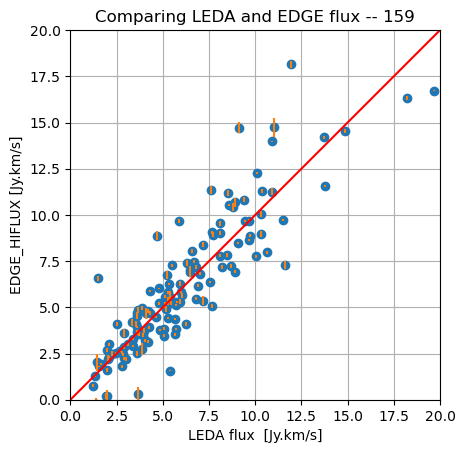

In [105]:
fig, ax = plt.subplots()
flux1 = leda['ledaHIflux']
flux3 = leda['SigInt']
eflux3 = leda['SigUnc']
cnt1 = len(flux1)

ax.plot(flux1, flux3, 'o')
ax.errorbar(flux1, flux3, yerr=eflux3 ,ls='none')
fmin = 0
fmax = 20
ax.set_xlim(fmin,fmax)
ax.set_ylim(fmin,fmax)
ax.grid()
ax.set_aspect('equal')
ax.plot([fmin,fmax],[fmin,fmax],'-', color='red')
ax.set_xlabel("LEDA flux  [Jy.km/s]")
ax.set_ylabel("EDGE_HIFLUX [Jy.km/s]")
ax.set_title(f"Comparing LEDA and EDGE flux -- {cnt1}")
print(flux1.max(), flux3.max())

In [ ]:
# fit a y=ax

# Cross matching catalogs

The catalogs (t0, t1, ....) are listed at the top of this notebook.

## 0. edge_califa

In [21]:
t0 = QTable.read('edge_califa.csv', format="ecsv")
t0

ID,Name,caSu,caSg,caSr,caSi,caB,caV,caR,caRe,caeRe,caEllipticity,caPA,caR50,caeR50,caR90,caeR90,cazgas,cazstars,caAge,caeAge,caAge_Re_fit,caeAge_Re_fit,caAge_alpha_fit,caeAge_alpha_fit,caAge_Re_fit_mw,caeAge_Re_fit_mw,caAge_alpha_fit_mw,caeAge_alpha_fit_mw,caFHa,caFHacorr,caLHacorr,caMstars,caeMstars,caMstarscorr,caSFR,caeSFR,caOH,caeOH,caOH_Re_fit,caeOH_Re_fit,caOH_alpha_fit,caeOH_alpha_fit,caOH_Re_fit_M08,caeOH_Re_fit_M08,caOH_alpha_fit_M08,caeOH_alpha_fit_M08,caAvgas,caeAvgas,caAvstars,caeAvstars,caDistP3d,caDistAng,caDistMpc,caFlgWav5,caFlgWav12,caFlgReg5,caFlgReg12,caFlgImg5,caFlgImg12
,,mag,mag,mag,mag,mag,mag,mag,arcsec,arcsec,,deg,arcsec,arcsec,arcsec,arcsec,,,dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(1e-16 erg / (s cm2)),dex(1e-16 erg / (s cm2)),dex(erg / s),dex(solMass),dex(solMass),dex(solMass),dex(solMass / yr),dex(solMass / yr),dex,dex,dex,dex,dex,dex,dex,dex,dex,dex,mag,mag,mag,mag,Mpc,Mpc,Mpc,,,,,,
int64,str23,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,IC5376,16.1851471079872,14.5148386558384,13.7746996210367,13.4152423076265,14.843331134221,14.109786555054,13.6956133607697,12.3533594260833,12.3533594260833,0.908298777642717,-86.6328412870503,14.5930861897852,0.580133286422324,39.8503507490289,0.0347700942141813,0.0166828002232699,0.0168304318230817,9.00921636199652,0.455905015787138,9.47029329320456,0.033373697585904,-0.424717157308448,0.0366186076544801,9.87122210809363,0.0158302942448841,-0.0113787373595571,0.0173694668538384,2.95946858763817,3.32444961005312,41.1168781882285,10.776715844314,0.104367367857885,10.7055607335975,0.0199681752204649,0.0595511264508334,8.50996204530593,0.0794470031628982,8.57379657876577,0.0135226263820659,-0.0479055738943362,0.0108332783268123,9.02900918200382,0.0205691008678075,0.0236736946644938,0.0164783665789037,1.39492131650746,0.151063952650176,0.5333289345863,0.984450288049397,71.98770098643776,69.62525974886516,72.39375643784535,0.0,0.0,0.0,1.0,0.0,0.0
2,UGC00005,15.2483065919008,14.1195941220309,13.5486392799929,13.2595749516228,14.3465821208416,13.8262788229319,13.4880400816455,20.2771195662004,20.2771195662004,0.836285736708902,-52.3187174424348,18.9515595557628,1.75042936323237,38.4605179219892,0.0280205074375317,0.0241986345275944,0.0241827738001353,8.91184972037966,0.412757304766495,9.15867209597674,0.0280138532930621,-0.344864900289066,0.0307376280374184,9.8270980548966,0.0281606451647009,-0.166789888636384,0.0308986924187496,3.43460867523136,3.88161456890663,41.993986953353,11.1192362635697,0.0854269039123404,11.0698528832268,0.897076940344901,0.05940876117232,8.54536704605116,0.0742684265982679,8.58715267366793,0.0200015718577077,-0.0190936711875484,0.0168108632339188,9.10676727932215,0.0400938510361776,-0.132170039440426,0.0336979638943007,1.5306335152532,0.106462160317965,0.309254153553231,0.693342148396912,104.04715441810822,99.19252656489616,105.62120034645841,0.0,0.0,0.0,0.0,0.0,0.0
3,NGC7819,15.4603954062173,14.5798509052481,14.1126097805191,13.9201432971941,14.761192584692,14.340216858187,14.0808253870926,15.1049879351976,15.1049879351976,0.871362684327647,-29.8714123412653,23.0121743761998,0.809684503319659,43.7792585693556,0.289541672473945,0.0164932924713098,0.016484375328998,8.67553505306613,0.366263582536238,9.02978353018453,0.0255296907157498,0.0856600971823328,0.0280119314155684,9.73051308519857,0.0495427404712661,-0.219286511077027,0.0543597595314485,3.46625134981103,3.71457429825972,41.4891312282872,10.4262028993743,0.0821361191644355,10.4755058428902,0.392221215279186,0.06004851420

## 1. edge_leda

In [22]:
t1 = QTable.read("edge_leda.csv", format="ecsv")
t1

Name,ledaName,ledaRA,ledaDE,ledaMorph,ledaBar,ledaRing,ledaMultiple,ledaType,ledaPA,ledaBt,ledaIt,ledaVmaxg,ledaFIR,ledaVrad,ledaA_Bgal,ledaIncl,ledaVrot,ledaVvir,ledaModz,ledaD25,ledaAxrat,ledaAxIncl,ledaDistMpc,ledaHIflux,ID
,,deg,deg,,,,,,deg,mag,mag,km / s,mag,km / s,mag,deg,km / s,km / s,mag,arcmin,,deg,Mpc,Jy km / s,
str23,str23,float64,float64,str4,str1,str1,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
2MASXJ01331766+1319567,2MASXJ01331766+1319567,23.3237175,13.3322413,Sc,B,--,--,5.9,176.69,15.223,13.975,90.83,———,2767.3,0.236,82.64,91.58,2749.1,33.005,1.68,0.2198,80.0,39.90,3.81,56
2MASXJ09065870,PGC3089961,136.7446155,20.7862729,E,--,--,--,-5.0,100.99,16.047,13.965,———,———,24090.7,0.198,90.0,———,24109.1,37.791,0.91,0.6607,55.9,361.58,———,3020
ARP118,NGC1143,43.7905275,-0.1778504,E,--,--,--,-4.3,110.65,14.268,13.485,———,———,8446.3,0.312,90.0,———,8322.1,35.423,1.22,0.5598,64.3,121.51,———,2943
ARP180,ARP180,73.352616,-4.7925158,--,--,--,--,--,19.5,15.62,13.3,———,———,4229.0,0.14,67.59,———,4054.5,33.845,1.20,0.4159,———,58.75,———,145
ARP220,ARP220,233.7387375,23.5028574,Sm,--,--,--,9.3,96.46,13.955,———,147.44,8.283,5427.0,0.22,56.98,175.83,5662.2,34.585,1.11,0.6471,50.0,82.60,18.30,802
BKD2008WR346,IC0225,36.617832,1.1605165,E,--,R,--,-4.9,157.79,14.831,13.486,———,———,1537.6,0.135,38.53,———,1432.2,31.639,1.01,0.8872,30.5,21.27,———,1003
CGCG163-062,CGCG163-062,217.2986835,30.0772529,SBc,B,R,--,5.0,20.0,15.381,14.198,13.89,———,4368.7,0.092,11.99,66.86,4603.3,34.132,0.68,0.9795,11.8,67.05,0.59,2752
CGCG242-073,CGCG242-073,175.197336,46.5405076,E,--,--,--,-5.0,160.16,15.082,13.275,———,———,16065.4,0.087,62.56,———,16273.7,36.905,1.19,0.7621,45.6,240.44,———,3026


In [23]:
t1_c = SkyCoord(t1["ledaRA"], t1["ledaDE"])

## 2. iedge


In [24]:
t2 = QTable.read("iedge_v1.ecsv", format="ecsv")
t2

CALIFA_name,Alias,RA,DEC,Vlsr,zstar,Distance,Incl,PA,Re_as,Glob_med_EWHa,Glob_Mstar,Glob_SFR,Glob_sSFR,Err_Glob_Mstar,Err_Glob_SFR,Err_Glob_sSFR,Glob_Gas_Met,Glob_alpha_co10_b13,Glob_R21,APEX_Glob_k2jypb,APEX_Glob_eta_mb,APEX_Glob_RMS,APEX_Glob_Tpeak,APEX_Glob_SNR,APEX_Glob_W50_mom2,APEX_Glob_eps_obs,APEX_Glob_Fco,APEX_Glob_Lco,APEX_Glob_Mmol,APEX_Glob_fmol,APEX_Glob_SFE,CARMA_Glob_k2jypb,CARMA_Glob_eta_mb,CARMA_Glob_RMS,CARMA_Glob_Tpeak,CARMA_Glob_SNR,CARMA_Glob_W50_mom2,CARMA_Glob_eps_obs,CARMA_Glob_Fco,CARMA_Glob_Lco,CARMA_Glob_Mmol,CARMA_Glob_fmol,CARMA_Glob_SFE,ACA_Glob_k2jypb,ACA_Glob_eta_mb,ACA_Glob_RMS,ACA_Glob_Tpeak,ACA_Glob_SNR,ACA_Glob_W50_mom2,ACA_Glob_eps_obs,ACA_Glob_Fco,ACA_Glob_Lco,ACA_Glob_Mmol,ACA_Glob_fmol,ACA_Glob_SFE,Final_Glob_Observatory,Final_Glob_SNR,Final_Glob_Mmol,Final_Glob_fmol,Final_Glob_SFE,APEX_Err_Glob_Fco,APEX_Err_Glob_Lco,APEX_Err_Glob_Mmol,APEX_Err_Glob_fmol,APEX_Err_Glob_SFE,CARMA_Err_Glob_Fco,CARMA_Err_Glob_Lco,CARMA_Err_Glob_Mmol,CARMA_Err_Glob_fmol,CARMA_Err_Glob_SFE,ACA_Err_Glob_Fco,ACA_Err_Glob_Lco,ACA_Err_Glob_Mmol,ACA_Err_Glob_fmol,ACA_Err_Glob_SFE,Final_Err_Glob_Mmol,Final_Err_Glob_fmol,Final_Err_Glob_SFE,Glob_L12um_w3_7p5,Err_Glob_L12um_w3_7p5,Beam_med_EWHa,Beam_Mstar,Beam_SFR,Beam_sSFR,Err_Beam_Mstar,Err_Beam_SFR,Err_Beam_sSFR,Beam_Gas_Met,Beam_alpha_co10_b13,Beam_R21,APEX_Beam_k2jypb,APEX_Beam_eta_mb,APEX_Beam_RMS,APEX_Beam_Tpeak,APEX_Beam_SNR,APEX_Beam_W50_mom2,APEX_Beam_eps_obs,APEX_Beam_Fco,APEX_Beam_Lco,APEX_Beam_Mmol,APEX_Beam_fmol,APEX_Beam_SFE,CARMA_Beam_k2jypb,CARMA_Beam_eta_mb,CARMA_Beam_RMS,CARMA_Beam_Tpeak,CARMA_Beam_SNR,CARMA_Beam_W50_mom2,CARMA_Beam_eps_obs,CARMA_Beam_Fco,CARMA_Beam_Lco,CARMA_Beam_Mmol,CARMA_Beam_fmol,CARMA_Beam_SFE,ACA_Beam_k2jypb,ACA_Beam_eta_mb,ACA_Beam_RMS,ACA_Beam_Tpeak,ACA_Beam_SNR,ACA_Beam_W50_mom2,ACA_Beam_eps_obs,ACA_Beam_Fco,ACA_Beam_Lco,ACA_Beam_Mmol,ACA_Beam_fmol,ACA_Beam_SFE,Final_Beam_Observatory,Final_Beam_SNR,Final_Beam_Mmol,Final_Beam_fmol,Final_Beam_SFE,APEX_Err_Beam_Fco,APEX_Err_Beam_Lco,APEX_Err_Beam_Mmol,APEX_Err_Beam_fmol,APEX_Err_Beam_SFE,CARMA_Err_Beam_Fco,CARMA_Err_Beam_Lco,CARMA_Err_Beam_Mmol,CARMA_Err_Beam_fmol,CARMA_Err_Beam_SFE,ACA_Err_Beam_Fco,ACA_Err_Beam_Lco,ACA_Err_Beam_Mmol,ACA_Err_Beam_fmol,ACA_Err_Beam_SFE,Final_Err_Beam_Mmol,Final_Err_Beam_fmol,Final_Err_Beam_SFE,Beam_L12um_w3_7p5,Err_Beam_L12um_w3_7p5,CARMA_conf,Morphology,Final_QS,Final_NA,Final_flag_QS,Final_flag_NA
,,deg,deg,km / s,,Mpc,deg,deg,arcsec,Angstrom,solMass,solMass / yr,1 / yr,solMass,solMass / yr,1 / yr,,s solMass / (K km pc2),,Jy / K,,K,K,,km / s,K km / s,K km / s,pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,,,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,solMass,,1 / yr,solLum,solLum,Angstrom,solMass,solMass / yr,1 / yr,solMass,solMass / yr,1 / yr,,s solMass / (K km pc2),,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,,,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,solMass,,1 / yr,solLum,solLum,,,,,,
str22,str27,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str5,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,f

In [25]:
t2_c = SkyCoord(t2["RA"], t2["DEC"])

Check overlap between t1 and t2 based on their coordinates.   it is surprising that this is not close,
limiting to 10" there are only 478/643.... odd.

In [26]:
idx, sep, _ = t1_c.match_to_catalog_sky(t2_c)

sep_max = 10
mask12 = sep < sep_max * u.arcsec
mask12.sum(), len(t2)

(np.int64(478), 643)

Text(0.5, 1.0, 'leda and iedge')

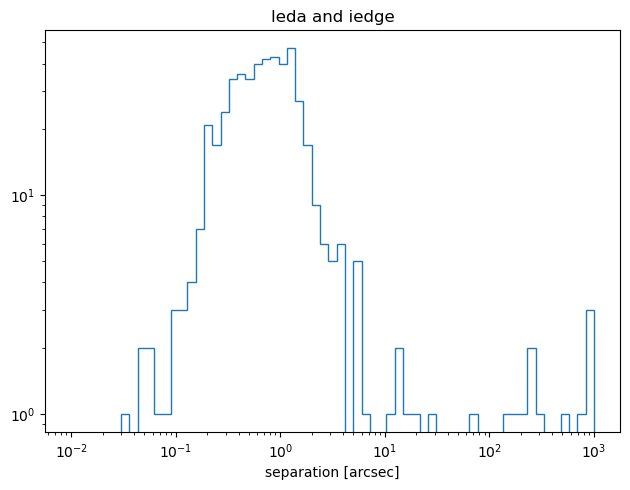

In [27]:
plt.hist(sep.arcsec, histtype="step", bins=np.logspace(-2, 3, 64))
plt.xlabel("separation [arcsec]")
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.title('leda and iedge');

## 3. edge_hiflux

In [152]:
t3 = QTable.read("edge_hiflux.csv", format="ecsv")
t3n = t3["Name"]

161

In [29]:
t31 = join(t3,t1)   # 159
# t31

1.2314024122062155 Jy km / s 56.91149576288402 Jy km / s


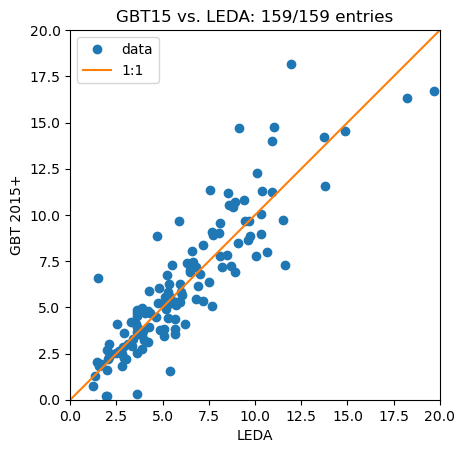

In [155]:
flux1 = t31["ledaHIflux"]
flux3 = t31["SigInt"]

idx3 = np.where(~np.isnan(flux3))[0]
#print(idx3)
cnt3 = len(idx3)

print(flux1.min(), flux1.max())
fmax = 20

fig,ax = plt.subplots()
ax.plot(flux1,flux3,'o',label="data")
ax.plot([0,fmax], [0,fmax], '-', label="1:1")
ax.set_xlim(0,fmax)
ax.set_ylim(0,fmax)
ax.set_aspect("equal")

ax.set_xlabel("LEDA")
ax.set_ylabel("GBT 2015+")
ax.legend()
ax.set_title(f"GBT15 vs. LEDA: {cnt3}/{len(t31)} entries");

## 4. edge2025

Provisional

In [31]:
t4 = Table.read("edge2025.csv", format="ecsv")

In [32]:
# add coordinates
t41 = join(t4,t1)    # 43

15.317927158934168 Jy km / s 63.279998779296875 Jy km / s


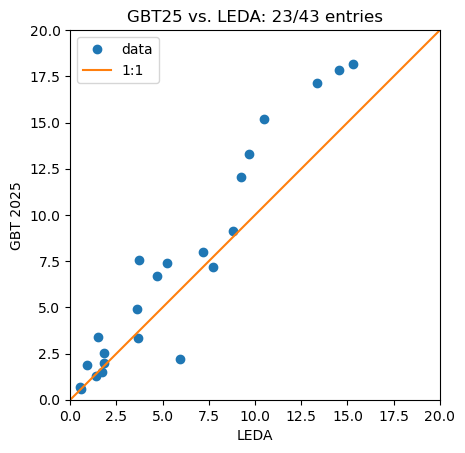

In [159]:
flux1 = t41["ledaHIflux"]
flux4 = t41["SigInt"]

print(flux1.max(), flux4.max())

idx = np.where(~np.isnan(flux1))[0]
cnt = len(idx)

fmax=20

fig,ax = plt.subplots()
ax.plot(flux1[idx],flux4[idx],'o',label="data")
ax.plot([0,fmax], [0,fmax], '-', label="1:1")
ax.set_xlim(0,fmax)
ax.set_ylim(0,fmax)
ax.set_aspect("equal")
ax.set_xlabel("LEDA")
ax.set_ylabel("GBT 2025")
ax.legend();
ax.set_title(f"GBT25 vs. LEDA: {cnt}/{len(flux4)} entries");

In [34]:
# Create mask and extract rows
mask = np.isin(t2['CALIFA_name'], t3n)
t2_3 = t2[mask]
len(t2),len(t2_3)

(643, 161)

In [35]:
t14 = common(t1,t4,"ledaName","Name")
t14

common 647 43 -> 41


Name,ledaName,ledaRA,ledaDE,ledaMorph,ledaBar,ledaRing,ledaMultiple,ledaType,ledaPA,ledaBt,ledaIt,ledaVmaxg,ledaFIR,ledaVrad,ledaA_Bgal,ledaIncl,ledaVrot,ledaVvir,ledaModz,ledaD25,ledaAxrat,ledaAxIncl,ledaDistMpc,ledaHIflux,ID
,,deg,deg,,,,,,deg,mag,mag,km / s,mag,km / s,mag,deg,km / s,km / s,mag,arcmin,,deg,Mpc,Jy km / s,
str23,str23,float64,float64,str4,str1,str1,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
IC0674,IC0674,167.776497,43.633019,Sab,B,R,--,2.0,121.03,14.356,12.945,241.85,———,7507.0,0.064,85.27,242.68,7691.6,35.252,1.37,0.3020,76.9,112.31,3.70,381
IC2341,IC2341,125.922615,21.4348704,E-S0,--,--,--,-3.1,2.58,14.639,12.432,———,———,5132.6,0.212,90.0,———,5133.3,34.37,1.18,0.4842,68.9,74.82,———,197
IC4215,IC4215,199.070475,25.405678,Sab,--,--,--,2.0,45.51,14.627,13.246,158.87,13.842,3883.6,0.071,90.0,158.87,4068.2,33.866,1.55,0.2344,83.2,59.32,0.51,615
MCG-01-01-012,MCG-01-01-012,359.795061,-4.1919115,Sb,--,--,--,3.2,70.0,15.05,12.62,171.6,———,5764.6,0.159,90.0,171.6,5719.1,34.601,1.57,0.2173,82.9,83.21,1.50,936
MCG-01-52-012,MCG-01-52-012,309.4582725,-6.0907463,E,--,--,--,-4.0,72.73,14.659,12.895,———,———,3859.0,0.265,60.02,———,3929.3,33.778,1.16,0.7244,48.2,56.96,———,3039
NGC0681,NGC0681,27.2951475,-10.4265532,SABa,B,R,--,2.0,66.75,12.769,11.476,172.17,11.831,1748.1,0.149,46.28,238.21,1607.5,31.863,2.51,0.7228,44.9,23.58,14.53,61
NGC0787,NGC0787,30.2024025,-9.0027307,Sb,--,R,--,3.0,91.23,13.627,11.797,162.24,———,4746.9,0.123,48.21,217.59,4606.7,34.132,1.87,0.6934,47.1,67.05,———,75
NGC0991,NGC0991,38.886213,-7.1544011,SABc,B,R,M,5.2,152.0,12.96,12.051,33.62,13.122,1531.8,0.12,28.1,71.37,1383.4,31.518,1.48,0.8872,27.8,20.12,15.32,95


In [36]:
a=common(t2,t3,"CALIFA_name","Name")
b=common(t3,t2,"Name","CALIFA_name")

common 643 161 -> 161
common 161 643 -> 161


In [37]:
a

CALIFA_name,Alias,RA,DEC,Vlsr,zstar,Distance,Incl,PA,Re_as,Glob_med_EWHa,Glob_Mstar,Glob_SFR,Glob_sSFR,Err_Glob_Mstar,Err_Glob_SFR,Err_Glob_sSFR,Glob_Gas_Met,Glob_alpha_co10_b13,Glob_R21,APEX_Glob_k2jypb,APEX_Glob_eta_mb,APEX_Glob_RMS,APEX_Glob_Tpeak,APEX_Glob_SNR,APEX_Glob_W50_mom2,APEX_Glob_eps_obs,APEX_Glob_Fco,APEX_Glob_Lco,APEX_Glob_Mmol,APEX_Glob_fmol,APEX_Glob_SFE,CARMA_Glob_k2jypb,CARMA_Glob_eta_mb,CARMA_Glob_RMS,CARMA_Glob_Tpeak,CARMA_Glob_SNR,CARMA_Glob_W50_mom2,CARMA_Glob_eps_obs,CARMA_Glob_Fco,CARMA_Glob_Lco,CARMA_Glob_Mmol,CARMA_Glob_fmol,CARMA_Glob_SFE,ACA_Glob_k2jypb,ACA_Glob_eta_mb,ACA_Glob_RMS,ACA_Glob_Tpeak,ACA_Glob_SNR,ACA_Glob_W50_mom2,ACA_Glob_eps_obs,ACA_Glob_Fco,ACA_Glob_Lco,ACA_Glob_Mmol,ACA_Glob_fmol,ACA_Glob_SFE,Final_Glob_Observatory,Final_Glob_SNR,Final_Glob_Mmol,Final_Glob_fmol,Final_Glob_SFE,APEX_Err_Glob_Fco,APEX_Err_Glob_Lco,APEX_Err_Glob_Mmol,APEX_Err_Glob_fmol,APEX_Err_Glob_SFE,CARMA_Err_Glob_Fco,CARMA_Err_Glob_Lco,CARMA_Err_Glob_Mmol,CARMA_Err_Glob_fmol,CARMA_Err_Glob_SFE,ACA_Err_Glob_Fco,ACA_Err_Glob_Lco,ACA_Err_Glob_Mmol,ACA_Err_Glob_fmol,ACA_Err_Glob_SFE,Final_Err_Glob_Mmol,Final_Err_Glob_fmol,Final_Err_Glob_SFE,Glob_L12um_w3_7p5,Err_Glob_L12um_w3_7p5,Beam_med_EWHa,Beam_Mstar,Beam_SFR,Beam_sSFR,Err_Beam_Mstar,Err_Beam_SFR,Err_Beam_sSFR,Beam_Gas_Met,Beam_alpha_co10_b13,Beam_R21,APEX_Beam_k2jypb,APEX_Beam_eta_mb,APEX_Beam_RMS,APEX_Beam_Tpeak,APEX_Beam_SNR,APEX_Beam_W50_mom2,APEX_Beam_eps_obs,APEX_Beam_Fco,APEX_Beam_Lco,APEX_Beam_Mmol,APEX_Beam_fmol,APEX_Beam_SFE,CARMA_Beam_k2jypb,CARMA_Beam_eta_mb,CARMA_Beam_RMS,CARMA_Beam_Tpeak,CARMA_Beam_SNR,CARMA_Beam_W50_mom2,CARMA_Beam_eps_obs,CARMA_Beam_Fco,CARMA_Beam_Lco,CARMA_Beam_Mmol,CARMA_Beam_fmol,CARMA_Beam_SFE,ACA_Beam_k2jypb,ACA_Beam_eta_mb,ACA_Beam_RMS,ACA_Beam_Tpeak,ACA_Beam_SNR,ACA_Beam_W50_mom2,ACA_Beam_eps_obs,ACA_Beam_Fco,ACA_Beam_Lco,ACA_Beam_Mmol,ACA_Beam_fmol,ACA_Beam_SFE,Final_Beam_Observatory,Final_Beam_SNR,Final_Beam_Mmol,Final_Beam_fmol,Final_Beam_SFE,APEX_Err_Beam_Fco,APEX_Err_Beam_Lco,APEX_Err_Beam_Mmol,APEX_Err_Beam_fmol,APEX_Err_Beam_SFE,CARMA_Err_Beam_Fco,CARMA_Err_Beam_Lco,CARMA_Err_Beam_Mmol,CARMA_Err_Beam_fmol,CARMA_Err_Beam_SFE,ACA_Err_Beam_Fco,ACA_Err_Beam_Lco,ACA_Err_Beam_Mmol,ACA_Err_Beam_fmol,ACA_Err_Beam_SFE,Final_Err_Beam_Mmol,Final_Err_Beam_fmol,Final_Err_Beam_SFE,Beam_L12um_w3_7p5,Err_Beam_L12um_w3_7p5,CARMA_conf,Morphology,Final_QS,Final_NA,Final_flag_QS,Final_flag_NA
,,deg,deg,km / s,,Mpc,deg,deg,arcsec,Angstrom,solMass,solMass / yr,1 / yr,solMass,solMass / yr,1 / yr,,s solMass / (K km pc2),,Jy / K,,K,K,,km / s,K km / s,K km / s,pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,,,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,solMass,,1 / yr,solLum,solLum,Angstrom,solMass,solMass / yr,1 / yr,solMass,solMass / yr,1 / yr,,s solMass / (K km pc2),,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,,,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,solMass,,1 / yr,solLum,solLum,,,,,,
str22,str27,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str5,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,f

In [38]:
b


Name,Refcode,Vsys,Deltav,Robust_rms,RefInt,RefUnc,SigInt,SigUnc,SigVmin,SigVmax,BadFlag
,,km / s,km / s,mJy,Jy km / s,Jy km / s,Jy km / s,Jy km / s,km / s,km / s,
str13,str8,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool
ARP220,edge2015,5427.0,10.57509994506836,1.9198100566864014,-15.375900268554688,0.2158139944076538,-15.343700408935547,0.3378939926624298,3965.64990234375,6919.97021484375,True
IC0480,edge2015,4624.2998046875,10.514699935913086,0.806439995765686,4.569310188293457,0.0901385024189949,4.368420124053955,0.05157890170812607,4429.47021484375,4821.419921875,False
IC0540,edge2015,2042.4000244140625,10.343799591064453,1.3626400232315063,1.5664399862289429,0.15115100145339966,1.294010043144226,0.08456920087337494,1872.1300048828125,2250.389892578125,False
IC0944,shg2005,6995.89990234375,8.699999809265137,1.5737799406051636,2.427799940109253,0.15730799734592438,2.505880117416382,0.12169600278139114,6666.0498046875,7357.93994140625,False
IC1151,edge2015,2173.199951171875,10.382499694824219,1.7496600151062012,7.545670032501221,0.1948069930076599,7.9736199378967285,0.09782619774341583,2020.97998046875,2317.93994140625,False
IC1199,edge2015,4724.7001953125,10.527000427246094,2.612920045852661,-0.4789139926433563,0.2923949956893921,0.3363969922065735,0.3277739882469177,4503.259765625,6022.919921875,True
IC1256,shg2005,4733.0,8.399999618530273,1.3512400388717651,8.980010032653809,0.13477900624275208,9.052590370178223,0.09895090013742447,4298.77001953125,4939.43017578125,False
IC1683,shg2005,4881.7998046875,8.5,1.218250036239624,0.7956439852714539,0.12296099960803986,0.7682989835739136,0.07467210292816162,4654.580078125,5101.31005859375,False


## 5. CALIFA_HI_sample_archive

In [39]:
t5 = QTable.read("CALIFA_HI_sample_archive.csv")
len(t5)

923

In [40]:
t5y = t5[t5["Archive_HI?"] == "Y"]
len(t5y)

562

In [41]:
t5n = t5[t5["Archive_HI?"] == "N"]
len(t5n)

361

In [42]:
t5_c  = SkyCoord(t5['RA']*u.deg, t5['DEC']*u.deg)
t5y_c = SkyCoord(t5y['RA']*u.deg,t5y['DEC']*u.deg)
t5n_c = SkyCoord(t5n['RA']*u.deg,t5n['DEC']*u.deg)

Text(0.5, 1.0, 'CALIFA -- 923')

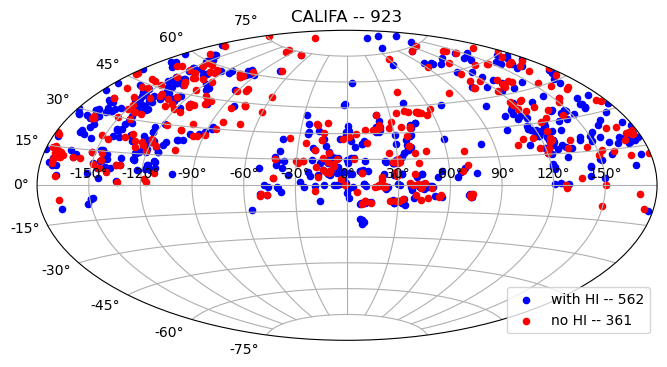

In [43]:
plt.figure(figsize=(8, 4.2))
ax = plt.subplot(111, projection="aitoff")
ax.grid(True)

coords = t5y_c
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian
cnt1 = len(coords)
ax.scatter(ra_rad, dec_rad, color='blue', s=20, label=f"with HI -- {cnt1}")

coords = t5n_c
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian
cnt2 = len(coords)
ax.scatter(ra_rad, dec_rad, color='red', s=20, label=f"no HI -- {cnt2}")
ax.legend(loc="lower right")
ax.set_title(f'CALIFA -- {cnt1+cnt2}')

## a100: ALFALFA

In [44]:
a100 = QTable.read('a100.code12.table2.190808.csv', format="csv")

In [45]:
a100


AGCNr,Name,RAdeg_HI,DECdeg_HI,RAdeg_OC,DECdeg_OC,Vhelio,W50,sigW,W20,HIflux,sigflux,SNR,RMS,Dist,sigDist,logMH,siglogMH,HIcode
int64,str8,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,int64
105367,........,0.00167,5.44333,0.00333,5.4425,11983,274,39,281,1.14,0.08,8.1,1.91,166.0,2.3,9.87,0.05,1
333313,........,0.00375,24.90889,359.9975,24.9075,11181,313,20,333,1.8,0.09,11.3,2.02,154.8,2.3,10.01,0.05,1
331060,478-009b,0.01042,23.08472,0.01417,23.0875,4463,160,4,184,1.96,0.07,14.7,2.35,50.6,10.4,9.07,0.18,1
331061,456-013.,0.01042,15.87222,0.00875,15.88167,6007,260,45,268,1.13,0.09,6.5,2.4,85.2,2.4,9.29,0.06,1
104570,........,0.00667,32.70834,0.005,32.71028,10614,245,6,250,0.86,0.07,6.6,1.86,147.0,2.3,9.64,0.06,1
331405,........,0.01375,26.01639,0.01458,26.01389,10409,315,8,345,2.62,0.09,16.1,2.05,143.8,2.2,10.11,0.05,1
102896,........,0.02833,28.20194,0.025,28.20194,16254,406,17,433,2.37,0.12,11.2,2.31,227.4,2.2,10.46,0.05,1
630358,382-015.,0.03125,-0.04694,0.0325,-0.04056,7089,70,9,103,2.47,0.06,29.7,2.2,96.2,2.3,9.73,0.05,1
105368,........,0.04542,4.28167,0.04875,4.27694,3845,83,6,94,0.72,0.06,7.5,2.33,54.2,2.2,8.7,0.07,1


In [46]:
#a100_c = SkyCoord(a100["RAdeg_HI"]*u.deg, a100["DECdeg_HI"]*u.deg)
a100_c = SkyCoord(a100["RAdeg_OC"]*u.deg, a100["DECdeg_OC"]*u.deg)

/tmp/ipykernel_174708/3371684337.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")


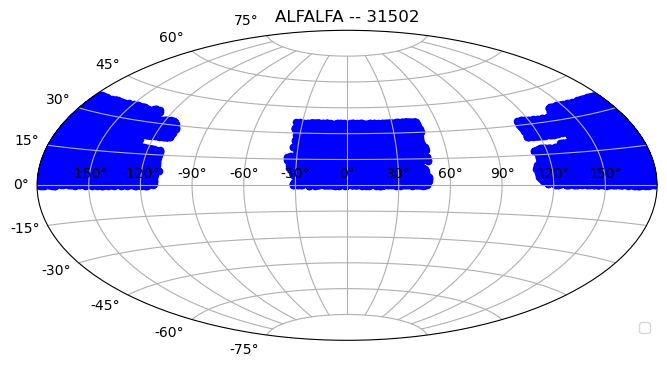

In [47]:
plt.figure(figsize=(8, 4.2))
ax = plt.subplot(111, projection="aitoff")
ax.grid(True)

coords = a100_c
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian
cnt = len(coords)
ax.scatter(ra_rad, dec_rad, color='blue', s=20)
ax.legend(loc="lower right")
ax.set_title(f'ALFALFA -- {cnt}');

## FAST

FASHI = HI_source catalog from FAST

In [48]:
# first two rows are header:  one for column name,one for unit
fast = Table.read('Table2-FASHI_extragalactic_HI_source_catalog.csv', format="ascii.csv")
fast.remove_row(0)
fast

ID_FASHI,Name,ra,dec,ra-dec_err,cz,cz_err,cz_min,cz_max,v_radio,v_radio_err,freq,freq_err,z,z_err,ell_maj,ell_min,ell_pa,W_50,W_50_err,W_20,W_20_err,F_peak,F_peak_err,S_bf,S_bf_err,S_sum,S_sum_err,rms,SNR,distance,distance_err,log10Mass,log10Mass_err
int64,str19,str8,str7,str6,str8,str4,str8,str8,str8,str4,str9,str6,float64,float64,str6,str6,str6,str6,str5,str6,str5,str8,str5,str10,str8,str10,str8,str5,float64,str6,str5,str9,str9
20230000823,J110656.76-061135.4,166.7365,-6.1932,0.0024,6802.07,0.77,6656.84,7014.73,6651.16,0.77,1388.8928,0.0037,0.02269,3e-06,3.7,3.7,0,164.01,1.55,172.62,2.32,9.05,1.79,1179.44,81.68,1046.79,81.68,1.79,20.35,98.18,4.91,9.42,0.05
20230000824,J073425.57-061135.2,113.6066,-6.1931,0.0019,10797.36,1.52,10569.21,10977.96,10422.00,1.52,1371.0267,0.0072,0.03602,5e-06,4.4,4.4,0,149.67,3.03,199.48,4.55,16.52,2.87,2221.25,138.81,2150.54,138.81,2.87,24.98,143.68,7.18,10.02,0.05
20230000825,J110530.38-061111.6,166.3766,-6.1866,0.0015,7596.64,0.62,7513.62,7676.58,7408.90,0.62,1385.3027,0.0029,0.02534,2e-06,5.0,4.9,106,32.96,1.24,46.53,1.86,33.25,2.41,1118.91,71.55,1098.33,71.55,2.41,31.9,108.32,5.42,9.48,0.05
20230042078,J111623.40-061056.9,169.0975,-6.1825,0.0052,24776.68,2.94,24469.20,24991.27,22885.30,2.94,1311.9760,0.0139,0.08265,1.1e-05,5.0,5.0,0,94.47,5.88,120.84,8.82,7.61,2.81,648.51,147.58,568.00,147.58,2.81,9.38,327.57,16.38,10.18,0.11
20230000826,J072644.69-061053.7,111.6862,-6.1816,0.0043,19246.13,2.01,19002.04,19521.14,18085.10,2.01,1334.7192,0.0095,0.0642,8e-06,2.3,2.3,0,198.62,4.02,216.39,6.03,2.39,1.18,474.51,62.99,504.00,62.99,1.18,11.25,253.69,12.68,9.83,0.07
20230042079,J110203.59-061042.3,165.5150,-6.1784,0.0037,9428.78,2.39,9235.63,9668.45,9141.28,2.39,1377.0947,0.0113,0.03145,8e-06,6.0,3.8,174,249.84,4.78,284.51,7.17,7.05,2.65,1402.99,132.74,1201.04,132.74,2.65,13.22,134.61,6.73,9.76,0.06
20230000828,J105557.19-061026.4,163.9883,-6.1740,0.0023,10202.87,0.62,10011.17,10397.70,9867.06,0.62,1373.6560,0.0030,0.03403,2e-06,5.8,5.4,33,170.88,1.25,176.95,1.87,23.42,3.44,2407.14,161.63,2550.58,161.63,3.44,21.17,143.94,7.20,10.06,0.05
20230000831,J035449.57-061015.6,58.7066,-6.1710,0.0035,10984.34,3.87,10741.96,11283.17,10596.10,3.87,1370.2018,0.0183,0.03664,1.4e-05,3.3,3.3,0,133.73,7.74,231.78,11.61,7.77,2.55,1022.46,142.33,984.18,142.33,2.55,13.73,151.95,7.60,9.73,0.07
20230042080,J082249.17-061008.6,125.7049,-6.1691,0.0037,14644.66,2.27,14471.52,14840.90,13962.60,2.27,1354.2515,0.0107,0.04885,8e-06,5.5,4.5,142,70.73,4.54,101.20,6.80,13.87,3.58,994.43,161.76,715.78,161.76,3.58,13.06,196.07,9.80,9.93,0.08


In [49]:
ra = fast["ra"].astype(float)*u.deg
de = fast['dec'].astype(float)*u.deg
fast_c = SkyCoord(ra,de)

/tmp/ipykernel_174708/1281546256.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")


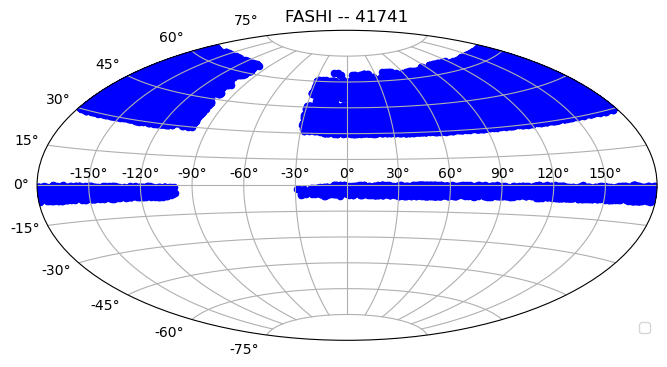

In [50]:
plt.figure(figsize=(8, 4.2))
ax = plt.subplot(111, projection="aitoff")
ax.grid(True)

coords = fast_c
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian
cnt = len(coords)
ax.scatter(ra_rad, dec_rad, color='blue', s=20)
ax.legend(loc="lower right")
ax.set_title(f'FASHI -- {cnt}');

In [51]:
t31 = join(t3,t1)   # 159
t31_c = SkyCoord(t31["ledaRA"], t31["ledaDE"])
len(t31)

159

In [52]:
t32 = join(t3,t2, keys_right='CALIFA_name',keys_left='Name'   ) 
t32

Name,Refcode,Vsys,Deltav,Robust_rms,RefInt,RefUnc,SigInt,SigUnc,SigVmin,SigVmax,BadFlag,CALIFA_name,Alias,RA,DEC,Vlsr,zstar,Distance,Incl,PA,Re_as,Glob_med_EWHa,Glob_Mstar,Glob_SFR,Glob_sSFR,Err_Glob_Mstar,Err_Glob_SFR,Err_Glob_sSFR,Glob_Gas_Met,Glob_alpha_co10_b13,Glob_R21,APEX_Glob_k2jypb,APEX_Glob_eta_mb,APEX_Glob_RMS,APEX_Glob_Tpeak,APEX_Glob_SNR,APEX_Glob_W50_mom2,APEX_Glob_eps_obs,APEX_Glob_Fco,APEX_Glob_Lco,APEX_Glob_Mmol,APEX_Glob_fmol,APEX_Glob_SFE,CARMA_Glob_k2jypb,CARMA_Glob_eta_mb,CARMA_Glob_RMS,CARMA_Glob_Tpeak,CARMA_Glob_SNR,CARMA_Glob_W50_mom2,CARMA_Glob_eps_obs,CARMA_Glob_Fco,CARMA_Glob_Lco,CARMA_Glob_Mmol,CARMA_Glob_fmol,CARMA_Glob_SFE,ACA_Glob_k2jypb,ACA_Glob_eta_mb,ACA_Glob_RMS,ACA_Glob_Tpeak,ACA_Glob_SNR,ACA_Glob_W50_mom2,ACA_Glob_eps_obs,ACA_Glob_Fco,ACA_Glob_Lco,ACA_Glob_Mmol,ACA_Glob_fmol,ACA_Glob_SFE,Final_Glob_Observatory,Final_Glob_SNR,Final_Glob_Mmol,Final_Glob_fmol,Final_Glob_SFE,APEX_Err_Glob_Fco,APEX_Err_Glob_Lco,APEX_Err_Glob_Mmol,APEX_Err_Glob_fmol,APEX_Err_Glob_SFE,CARMA_Err_Glob_Fco,CARMA_Err_Glob_Lco,CARMA_Err_Glob_Mmol,CARMA_Err_Glob_fmol,CARMA_Err_Glob_SFE,ACA_Err_Glob_Fco,ACA_Err_Glob_Lco,ACA_Err_Glob_Mmol,ACA_Err_Glob_fmol,ACA_Err_Glob_SFE,Final_Err_Glob_Mmol,Final_Err_Glob_fmol,Final_Err_Glob_SFE,Glob_L12um_w3_7p5,Err_Glob_L12um_w3_7p5,Beam_med_EWHa,Beam_Mstar,Beam_SFR,Beam_sSFR,Err_Beam_Mstar,Err_Beam_SFR,Err_Beam_sSFR,Beam_Gas_Met,Beam_alpha_co10_b13,Beam_R21,APEX_Beam_k2jypb,APEX_Beam_eta_mb,APEX_Beam_RMS,APEX_Beam_Tpeak,APEX_Beam_SNR,APEX_Beam_W50_mom2,APEX_Beam_eps_obs,APEX_Beam_Fco,APEX_Beam_Lco,APEX_Beam_Mmol,APEX_Beam_fmol,APEX_Beam_SFE,CARMA_Beam_k2jypb,CARMA_Beam_eta_mb,CARMA_Beam_RMS,CARMA_Beam_Tpeak,CARMA_Beam_SNR,CARMA_Beam_W50_mom2,CARMA_Beam_eps_obs,CARMA_Beam_Fco,CARMA_Beam_Lco,CARMA_Beam_Mmol,CARMA_Beam_fmol,CARMA_Beam_SFE,ACA_Beam_k2jypb,ACA_Beam_eta_mb,ACA_Beam_RMS,ACA_Beam_Tpeak,ACA_Beam_SNR,ACA_Beam_W50_mom2,ACA_Beam_eps_obs,ACA_Beam_Fco,ACA_Beam_Lco,ACA_Beam_Mmol,ACA_Beam_fmol,ACA_Beam_SFE,Final_Beam_Observatory,Final_Beam_SNR,Final_Beam_Mmol,Final_Beam_fmol,Final_Beam_SFE,APEX_Err_Beam_Fco,APEX_Err_Beam_Lco,APEX_Err_Beam_Mmol,APEX_Err_Beam_fmol,APEX_Err_Beam_SFE,CARMA_Err_Beam_Fco,CARMA_Err_Beam_Lco,CARMA_Err_Beam_Mmol,CARMA_Err_Beam_fmol,CARMA_Err_Beam_SFE,ACA_Err_Beam_Fco,ACA_Err_Beam_Lco,ACA_Err_Beam_Mmol,ACA_Err_Beam_fmol,ACA_Err_Beam_SFE,Final_Err_Beam_Mmol,Final_Err_Beam_fmol,Final_Err_Beam_SFE,Beam_L12um_w3_7p5,Err_Beam_L12um_w3_7p5,CARMA_conf,Morphology,Final_QS,Final_NA,Final_flag_QS,Final_flag_NA
,,km / s,km / s,mJy,Jy km / s,Jy km / s,Jy km / s,Jy km / s,km / s,km / s,,,,deg,deg,km / s,,Mpc,deg,deg,arcsec,Angstrom,solMass,solMass / yr,1 / yr,solMass,solMass / yr,1 / yr,,s solMass / (K km pc2),,Jy / K,,K,K,,km / s,K km / s,K km / s,pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,,,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,solMass,,1 / yr,solLum,solLum,Angstrom,solMass,solMass / yr,1 / yr,solMass,solMass / yr,1 / yr,,s solMass / (K km pc2),,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,,,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,solMass,,1 / yr,solLum,solLum,,,,,,
str13,str8,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool,str22,str27,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,flo

In [53]:
join(t5,t1,keys_left='CALIFA_name',keys_right='Name')


CALIFA_name,RA,DEC,Vlsr,Final_QS,Final_NA,Final_flag_QS,Final_flag_NA,Archive_HI?,Name,ledaName,ledaRA,ledaDE,ledaMorph,ledaBar,ledaRing,ledaMultiple,ledaType,ledaPA,ledaBt,ledaIt,ledaVmaxg,ledaFIR,ledaVrad,ledaA_Bgal,ledaIncl,ledaVrot,ledaVvir,ledaModz,ledaD25,ledaAxrat,ledaAxIncl,ledaDistMpc,ledaHIflux,ID
,,,,,,,,,,,deg,deg,,,,,,deg,mag,mag,km / s,mag,km / s,mag,deg,km / s,km / s,mag,arcmin,,deg,Mpc,Jy km / s,
str24,float64,float64,float64,str3,str4,int64,str1,str1,str23,str23,float64,float64,str4,str1,str1,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
2MASXJ01331766+1319567,23.3237353572048,13.3324282762911,2693.335767725673,SF,nonA,1,S,Y,2MASXJ01331766+1319567,2MASXJ01331766+1319567,23.3237175,13.3322413,Sc,B,--,--,5.9,176.69,15.223,13.975,90.83,———,2767.3,0.236,82.64,91.58,2749.1,33.005,1.68,0.2198,80.0,39.90,3.81,56
2MASXJ09065870,136.744555258512,20.7863461387406,23963.854082804482,MX,nonA,2,S,N,2MASXJ09065870,PGC3089961,136.7446155,20.7862729,E,--,--,--,-5.0,100.99,16.047,13.965,———,———,24090.7,0.198,90.0,———,24109.1,37.791,0.91,0.6607,55.9,361.58,———,3020
ARP118,43.794992607641,-0.179958964196501,8301.51810196398,MX,nonA,2,S,Y,ARP118,NGC1143,43.7905275,-0.1778504,E,--,--,--,-4.3,110.65,14.268,13.485,———,———,8446.3,0.312,90.0,———,8322.1,35.423,1.22,0.5598,64.3,121.51,———,2943
ARP180,73.3523736721931,-4.79281030209745,4185.983107147741,MX,nonA,2,U,N,ARP180,ARP180,73.352616,-4.7925158,--,--,--,--,--,19.5,15.62,13.3,———,———,4229.0,0.14,67.59,———,4054.5,33.845,1.20,0.4159,———,58.75,———,145
ARP220,233.739023856285,23.5036884217683,5442.300810588924,MX,sAGN,1,S,Y,ARP220,ARP220,233.7387375,23.5028574,Sm,--,--,--,9.3,96.46,13.955,———,147.44,8.283,5427.0,0.22,56.98,175.83,5662.2,34.585,1.11,0.6471,50.0,82.60,18.30,802
BKD2008WR346,36.6178089149218,1.1605206950304,1455.9657617286186,SF,nonA,2,S,N,BKD2008WR346,IC0225,36.617832,1.1605165,E,--,R,--,-4.9,157.79,14.831,13.486,———,———,1537.6,0.135,38.53,———,1432.2,31.639,1.01,0.8872,30.5,21.27,———,1003
CGCG163-062,217.298660276734,30.0773674228571,4306.69889503955,SF,nonA,1,S,Y,CGCG163-062,CGCG163-062,217.2986835,30.0772529,SBc,B,R,--,5.0,20.0,15.381,14.198,13.89,———,4368.7,0.092,11.99,66.86,4603.3,34.132,0.68,0.9795,11.8,67.05,0.59,2752
CGCG242-073,175.197280027654,46.5405728780359,16044.135596504191,nR,nonA,1,S,N,CGCG242-073,CGCG242-073,175.197336,46.5405076,E,--,--,--,-5.0,160.16,15.082,13.275,———,———,16065.4,0.087,62.56,———,16273.7,36.905,1.19,0.7621,45.6,240.44,———,3026


In [54]:
#t51 = join(t5,t1)

### Comparing CALIFA HI with ALFALFA

In [160]:
#   compare the ones where we have HI
idx, sep, _ = t5y_c.match_to_catalog_sky(a100_c)

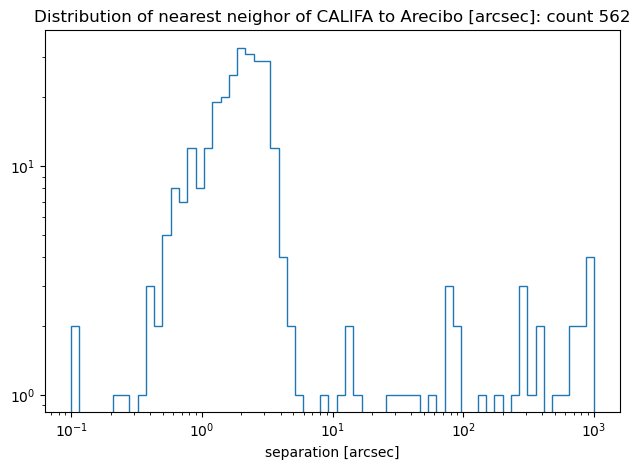

In [161]:
plt.hist(sep.arcsec, histtype="step", bins=np.logspace(-1, 3.0, 64))
plt.xlabel("separation [arcsec]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Distribution of nearest neighor of CALIFA to Arecibo [arcsec]: count {len(sep)}")
plt.tight_layout()

In [162]:
a100y = a100[idx]

dist_max = 10
mask5y = sep < dist_max * u.arcsec
mask5y.sum(), len(t5y_c)

m5 = common(t5y[mask5y], t1, 'CALIFA_name', 'Name', mask=True)    # 209 are true

a100y_near = a100y[mask5y]         # 268
flux100y = a100y_near['HIflux'][np.where(m5)] 
len(flux100y)

flux1y = t1['ledaHIflux'][np.where(m5)]

cnt1 = len(flux1y)

common 268 647 -> 209


56.91149576288402 Jy km / s 36.48


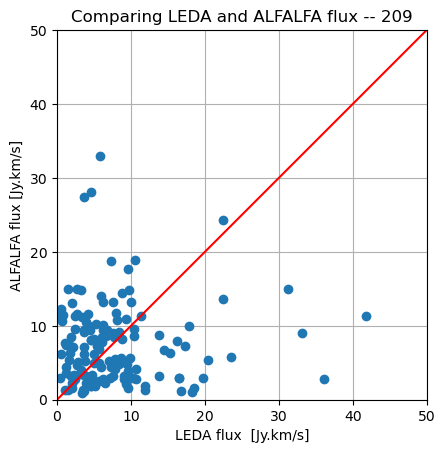

In [163]:
fig, ax = plt.subplots()
ax.plot(flux1y, flux100y, 'o')
fmin = 0
fmax = 50
ax.set_xlim(fmin,fmax)
ax.set_ylim(fmin,fmax)
ax.grid()
ax.set_aspect('equal')
ax.plot([fmin,fmax],[fmin,fmax],'-', color='red')
ax.set_xlabel("LEDA flux  [Jy.km/s]")
ax.set_ylabel("ALFALFA flux [Jy.km/s]")
ax.set_title(f"Comparing LEDA and ALFALFA flux -- {cnt1}")
print(flux1y.max(), flux100y.max())

this plot does not look good. it's too wrong, what did we do wrong?

In [169]:
# compare the ones where we don't have HI
idx, sep, _ = t5n_c.match_to_catalog_sky(a100_c)
a100n = a100[idx]

mask5n = sep < dist_max * u.arcsec
(sep < dist_max * u.arcsec).sum(), len(t5n_c)

(np.int64(15), 361)

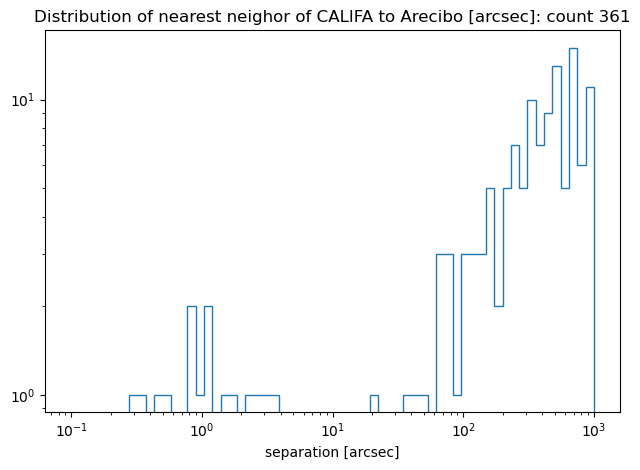

In [170]:
plt.hist(sep.arcsec, histtype="step", bins=np.logspace(-1, 3.0, 64))
plt.xlabel("separation [arcsec]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Distribution of nearest neighor of CALIFA to Arecibo [arcsec]: count {len(sep)}")
plt.tight_layout()

## TODO1

15 Galaxies of the Califa_HI=N cases have fluxes from ALFALFA, thus 346 candidates left

From the Califa_HI=Y there are 268 / 362 in ALFALFA, so good to compare their fluxes


In [171]:
#t5y[mask5y]

#a100y

#t5yf = common(t1, t5y[mask5y], "Name", "CALIFA_name")





In [172]:
#t5n[~mask5n]

In [173]:
idx2 = (sep < 10 * u.arcsec)
print(idx2.sum())
t5na = t5n[~idx2]
print(len(t5na))  # 346

15
346


In [175]:
# find the ones common in iedge
mask52 = common(t5na, t2, "CALIFA_name", "CALIFA_name", mask=True)
print(len(mask52))
t5nai = t5na[mask52]

ascii.write(t5nai, 'todo1.txt', include_names=['CALIFA_name'], format='no_header', overwrite=True)

common 346 643 -> 176
346


In [178]:
mask25 = common(t2, t5nai, "CALIFA_name", "CALIFA_name", mask=True)
t2n = t2[mask25]
t2y = t2[~mask25]
print(len(t2n),len(t2y),len(t2))

common 643 176 -> 176
176 467 643


335


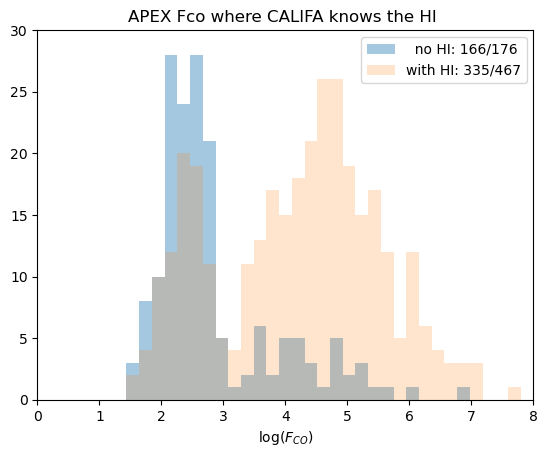

In [207]:
bins=np.linspace(0,8,40)

cnt1a = len(t2n)
cnt2a = len(t2y)

flux1 = np.log(t2n['APEX_Glob_Fco'].value)
flux2 = np.log(t2y['APEX_Glob_Fco'].value)
       
idx1 = np.where(~np.isnan(flux1))[0]
idx2 = np.where(~np.isnan(flux2))[0]

cnt1 = len(idx1)
cnt2 = len(idx2)

plt.hist(np.log(t2n['APEX_Glob_Fco'].value), bins=bins, alpha=0.4, label=f"  no HI: {cnt1}/{cnt1a}")
plt.hist(np.log(t2y['APEX_Glob_Fco'].value), bins=bins, alpha=0.2, label=f"with HI: {cnt2}/{cnt2a}")
 
plt.xlim(0,8)
plt.ylim(0,30)
plt.xlabel("log($F_{CO}$)")
plt.title(f"APEX Fco where CALIFA knows the HI ")
plt.legend();
print(cnt2)

There are only 40 with log(Fco) > 3


In [212]:
mask3 = np.log(t2n['APEX_Glob_Fco'].value) > 3
t2n_3 = t2n[mask3]
print(len(t2n_3))
ascii.write(t2n_3, 'todo2.txt', include_names=['CALIFA_name'], format='no_header', overwrite=True, comment="todo2")


40
40


In [64]:
see = ['APEX_Glob_Fco', 'APEX_Glob_eps_obs', 'APEX_Glob_RMS']
t2[see]

APEX_Glob_Fco,APEX_Glob_eps_obs,APEX_Glob_RMS
K km / s,K km / s,K
float64,float64,float64
34.59057407917514,0.04845150012045247,0.0006697489324822186
8.959220878181952,0.06030404597508842,0.0006356604580159633
9.55875026592507,0.09655303298914213,0.0010177583308102157
9.308881367717104,0.09272032721614899,0.0009773580646637672
322.12171969050297,0.11860466430521392,0.0009527346357704007
63.95597229360528,0.056859707983612603,0.0006512611835027063
3096.7728971060596,0.23600030138195996,0.0021515431606477353
78.74709225285471,0.09121355749980149,0.001327443533233896


In [65]:
fco = t2['APEX_Glob_Fco'].value 
mask = np.where(~np.isnan(fco))
len(mask[0])  # 501
fco = fco[mask]

fco_snr = t2['APEX_Glob_SNR'].value 
fco_snr = fco_snr[mask]

fco_snr = t2['APEX_Glob_eps_obs'].value 
fco_snr = fco_snr[mask]
fco_snr = fco/fco_snr 

/tmp/ipykernel_174708/2491732672.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


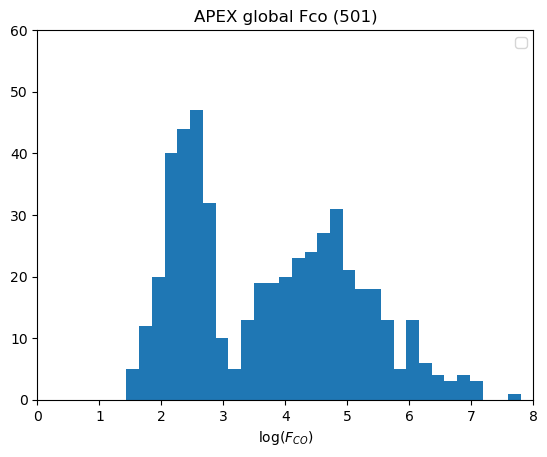

In [66]:
bins=np.linspace(0,8,40)

cnt = len(fco)

plt.hist(np.log(fco), bins=bins)
plt.xlim(0,8)
plt.ylim(0,60)
plt.xlabel("log($F_{CO}$)")
plt.title(f"APEX global Fco ({cnt})")
plt.legend();

/tmp/ipykernel_174708/740776862.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


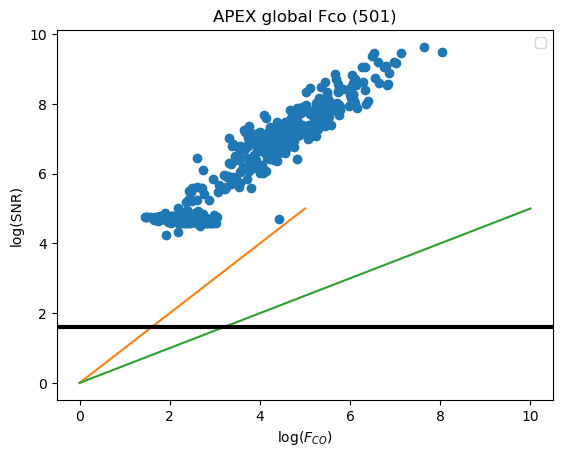

In [67]:
plt.plot(np.log(fco),np.log(fco_snr),'o')
plt.plot([0,5],[0,5])
plt.plot([0,10],[0,5])
plt.axhline(np.log(5), color='black', lw=3)
#plt.xlim(0,8)
#plt.ylim(-1,5)
plt.xlabel("log($F_{CO}$)")
plt.ylabel("log(SNR)")
plt.title(f"APEX global Fco ({cnt})")
plt.legend();

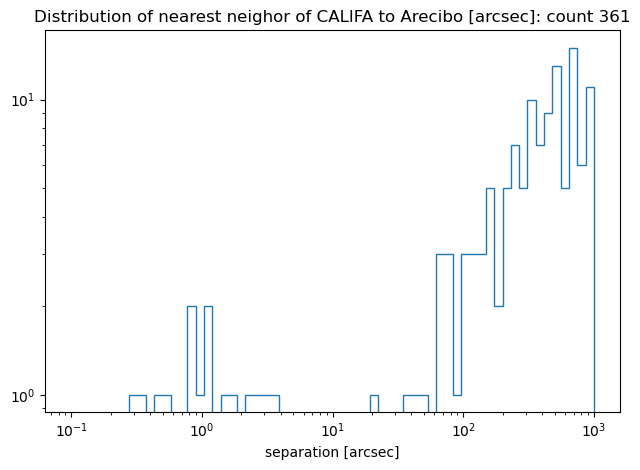

In [68]:
plt.hist(sep.arcsec, histtype="step", bins=np.logspace(-1, 3.0, 64))
plt.xlabel("separation [arcsec]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Distribution of nearest neighor of CALIFA to Arecibo [arcsec]: count {len(sep)}")
plt.tight_layout()

In [69]:
idx, sep, _ = t31_c.match_to_catalog_sky(a100_c)

(sep < 10 * u.arcsec).sum(), len(t31)

(np.int64(62), 159)

In [70]:
mask = sep < 10 * u.arcsec
mask

array([False,  True,  True,  True,  True,  True, False, False, False,
        True, False,  True,  True,  True, False,  True,  True, False,
       False,  True,  True, False, False, False, False, False, False,
        True,  True,  True, False,  True, False, False,  True,  True,
       False,  True, False,  True,  True, False,  True, False,  True,
        True, False, False, False,  True, False, False,  True, False,
       False,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False,  True, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False,  True,  True,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True,  True,
        True,  True, False, False, False, False,  True, False,  True,
       False,  True, False, False, False, False, False,  True,  True,
        True,  True,

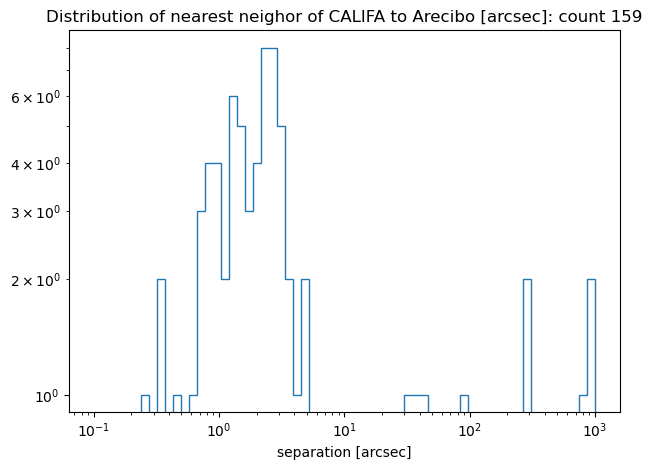

In [71]:
plt.hist(sep.arcsec, histtype="step", bins=np.logspace(-1, 3.0, 64))
plt.xlabel("separation [arcsec]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Distribution of nearest neighor of CALIFA to Arecibo [arcsec]: count {len(sep)}")
plt.tight_layout()

arguable all less than 10" are spot on. That's 62 out of the 159, not bad.

In [72]:
mask

array([False,  True,  True,  True,  True,  True, False, False, False,
        True, False,  True,  True,  True, False,  True,  True, False,
       False,  True,  True, False, False, False, False, False, False,
        True,  True,  True, False,  True, False, False,  True,  True,
       False,  True, False,  True,  True, False,  True, False,  True,
        True, False, False, False,  True, False, False,  True, False,
       False,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False,  True, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False,  True,  True,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True,  True,
        True,  True, False, False, False, False,  True, False,  True,
       False,  True, False, False, False, False, False,  True,  True,
        True,  True,

There are 23/159 galaxies in CALIFA_HI that seem to overlap with Arecibo, if HI location used. But 62 if the OC location!!

In [73]:
#a100_near = a100[mask]
a100_near = t31[mask]
print(len(a100_near))
a100_near["sep"] = sep.arcsec[mask]

62


In [74]:
#t31.keys()   # Name, SigInt, ledaHIflux

In [75]:
# add more columns.... I didn't know how to do the join here
a100_near["Name2"] = t31["Name"]
a100_near["SigInt"] = t31["SigInt"]

ValueError: Inconsistent data column lengths

In [ ]:
a100_near

Cut the 159 down to 62

In [ ]:
a100_near[see]

In [ ]:
see = ["AGCNr","Name","Name2","RAdeg_OC","DECdeg_OC","HIflux", "SigInt", "sep"]
idx2 = a100_near["sep"] < 10
a100_near2 = a100_near[idx2]
a100_near2[see]

In [ ]:
plt.plot(a100_near["HIflux"], a100_near["SigInt"],"o")
plt.plot([0,30],[0,30])
plt.xlabel("ALFALFA  [Jy.km/s]")
plt.ylabel("GBT++   [Jy.km/s]" )
plt.title(f"a100_near:  {len(a100_near['HIflux'])}")

ok, quite a lot of weak arecibo data have good GBT fluxes.  But not the other way around.  Need to see spectra.

In [ ]:
idx = np.where(a100_near["HIflux"] > 30)[0]
a100_near[idx]

## 6. hiedge_all

This is currently just a list of names of all the spectra Veselina obtained from NED

In [ ]:
# names of all the califa galaxies where hi was detected - and where not
t6 = QTable.read('hiedge_all.csv')


In [ ]:
see = ['CALIFA_name', 'APEX_Glob_Fco','CARMA_Glob_Fco','ACA_Glob_Fco']
t2g = t2[see]

In [ ]:
cnt, bins, patches = plt.hist(t2['APEX_Glob_Fco'], bins=32, log=True)
cnt1 = int(cnt.sum())


In [ ]:
cnt, bins, patches = plt.hist(t2['CARMA_Glob_Fco'], bins=32, log=True)
cnt2 = int(cnt.sum())

In [ ]:
cnt, bins, patches = plt.hist(t2['ACA_Glob_Fco'], bins=32, log=True)
cnt3 = int(cnt.sum())

In [ ]:
plt.hist(t2['APEX_Glob_Fco'], bins=32, log=True, label=f'APEX {cnt1}')
plt.hist(t2['CARMA_Glob_Fco'], bins=32, log=True, label=f'CARMA {cnt2}')
plt.hist(t2['ACA_Glob_Fco'], bins=32, log=True,   label=f'ACA {cnt3}')
plt.title("Count of cold gas detections")
plt.legend();


In [ ]:
t32g = join(t3, t2g, keys_left='Name', keys_right='CALIFA_name')

In [ ]:
idx = np.where(~np.isnan(t32g['APEX_Glob_Fco']))
print(idx)

In [ ]:
cnt = len(t32g['SigInt'][idx])

plt.plot(t32g['SigInt'][idx], t32g['APEX_Glob_Fco'][idx],'o')
plt.xlim(0,40)
plt.ylim(0,1500)
plt.xlabel("HI from edge_hiflux [Jy km/s]")
plt.ylabel("APEX_Glob_Fco [K km/s]")
plt.title(f"CO with HI : {cnt}");

How many of our t3 are in t5?

In [ ]:
c53 = common(t5,t3,'CALIFA_name','Name')

In [ ]:
c54 = common(t5,t4,'CALIFA_name','Name')

In [ ]:
c51 = common(t5,t1,'CALIFA_name','ledaName')
c51 = common(t5,t1,'CALIFA_name','Name')

## 7. amusing

## 8. xCOLDGASS

In [ ]:
t8 = QTable.read('xCOLDGASS.txt', format="ascii.tab")
t8_c = SkyCoord(t8['RA']*u.deg,t8['Dec']*u.deg)

In [ ]:
plt.figure(figsize=(8, 4.2))
ax = plt.subplot(111, projection="aitoff")
ax.grid(True)

coords = t8_c
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian
cnt = len(coords)
ax.scatter(ra_rad, dec_rad, color='blue', s=20)
ax.legend(loc="lower right")
ax.set_title(f'xCOLDGASS -- {cnt}');

In [ ]:
# comparing xCOLDGAS w/ CALIFA

idx, sep, _ = t5_c.match_to_catalog_sky(t8_c)

sep_max = 60
mask = (sep < sep_max * u.arcsec)
print(t5[mask])
print(len(mask))
#print(mask)

(sep < sep_max * u.arcsec).sum(), len(t8_c)

t8d = QTable.read('xCOLDGASS_PubCat.fits', format="fits")
t8d

## Comparing FAST and ALFALFA

There's a paper on this too.


In [ ]:
#idx, sep, _ = a100_c.match_to_catalog_sky(fast_c)
%time idx, sep, _ = fast_c.match_to_catalog_sky(a100_c)
(sep < 10 * u.arcsec).sum()

In [ ]:
len(fast_c),len(a100_c)

In [ ]:
plt.hist(sep.arcsec, histtype="step", bins=np.logspace(-1, 4, 64))
plt.xlabel("separation [arcsec]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Distribution of nearest neighor of ALFALFA vs. FASHI [arcsec]")
plt.tight_layout()